HW3_1_1

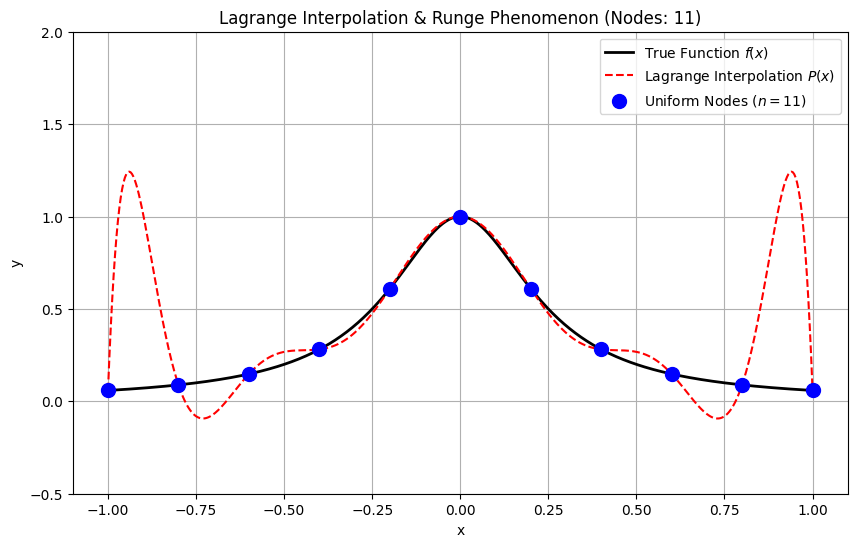

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return 1 / (1 + 16 * x**2)

def lagrange_basis(x_val, j, x_nodes):
    basis = 1.0
    xj = x_nodes[j]
    
    for i in range(len(x_nodes)):
        if i != j:
            xi = x_nodes[i]
            basis *= (x_val - xi) / (xj - xi)
            
    return basis

def lagrange_interpolating_poly(x_val, x_nodes, y_nodes):
    total_sum = 0.0
    n = len(x_nodes)
    
    for j in range(n):
        term = y_nodes[j] * lagrange_basis(x_val, j, x_nodes)
        total_sum += term
        
    return total_sum

x_nodes = np.linspace(-1, 1, 11) 
y_nodes = f(x_nodes)

x_dense = np.linspace(-1, 1, 500)
y_true = f(x_dense)
y_pred = [lagrange_interpolating_poly(x, x_nodes, y_nodes) for x in x_dense]

plt.figure(figsize=(10, 6))
plt.plot(x_dense, y_true, 'k-', linewidth=2, label='True Function $f(x)$') 
plt.plot(x_dense, y_pred, 'r--', linewidth=1.5, label='Lagrange Interpolation $P(x)$') 
plt.scatter(x_nodes, y_nodes, color='blue', s=100, zorder=5, label='Uniform Nodes ($n=11$)') 

plt.title(f'Lagrange Interpolation & Runge Phenomenon (Nodes: {len(x_nodes)})')
plt.xlabel('x')
plt.ylabel('y')
plt.ylim(-0.5, 2.0)
plt.legend()
plt.grid(True)
plt.show()

HW3_1_2

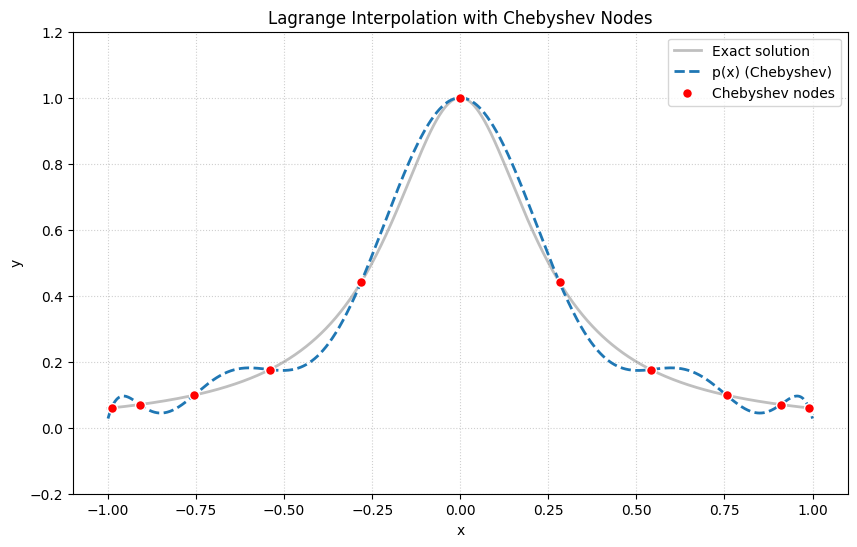

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import BarycentricInterpolator

def f(x):
    return 1 / (1 + 16 * x**2)

n = 10
i = np.arange(0, n + 1)

x_c = np.cos((2 * i + 1) * np.pi / (2 * n + 2))
y_c = f(x_c)

p_c = BarycentricInterpolator(x_c, y_c)

x_plot = np.linspace(-1, 1, 1000)

plt.figure(figsize=(10, 6))
plt.plot(x_plot, f(x_plot), color='gray', alpha=0.5, lw=2, label='Exact solution')
plt.plot(x_plot, p_c(x_plot), color='#1f77b4', linestyle='--', lw=2, label='p(x) (Chebyshev)')
plt.scatter(x_c, y_c, color='red', edgecolor='white', s=50, zorder=3, label='Chebyshev nodes')

plt.title('Lagrange Interpolation with Chebyshev Nodes')
plt.xlabel('x')
plt.ylabel('y')
plt.ylim(-0.2, 1.2)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

HW_3_1_3

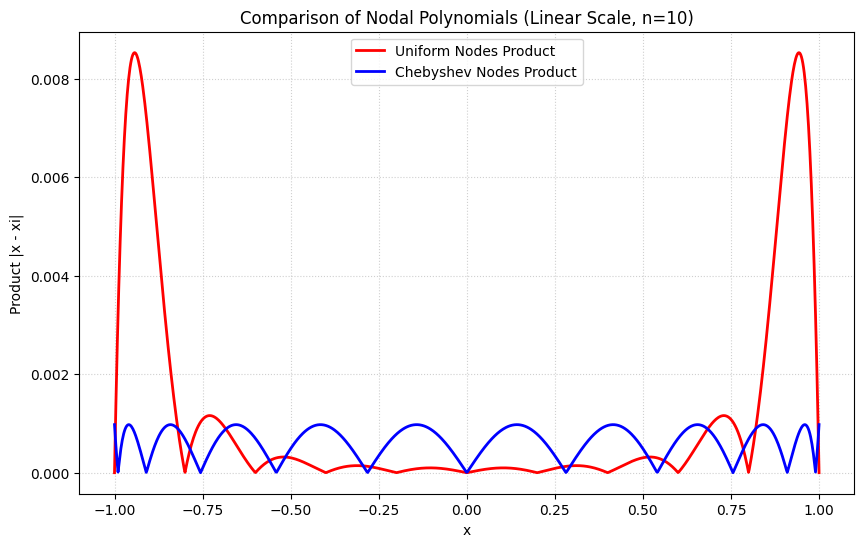

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def nodal_polynomial(x, nodes):
    result = np.ones_like(x)
    for xi in nodes:
        result *= np.abs(x - xi)
    return result

n = 10
i = np.arange(n + 1)

x_uni = np.linspace(-1, 1, n + 1)
x_cheb = np.cos((2 * i + 1) * np.pi / (2 * n + 2))

x_range = np.linspace(-1, 1, 1000)
y_uni = nodal_polynomial(x_range, x_uni)
y_cheb = nodal_polynomial(x_range, x_cheb)

plt.figure(figsize=(10, 6))

plt.plot(x_range, y_uni, 'r-', lw=2, label='Uniform Nodes Product')
plt.plot(x_range, y_cheb, 'b-', lw=2, label='Chebyshev Nodes Product')

plt.title(f'Comparison of Nodal Polynomials (Linear Scale, n={n})')
plt.xlabel('x')
plt.ylabel('Product |x - xi|')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

plt.show()

HW3_1_4

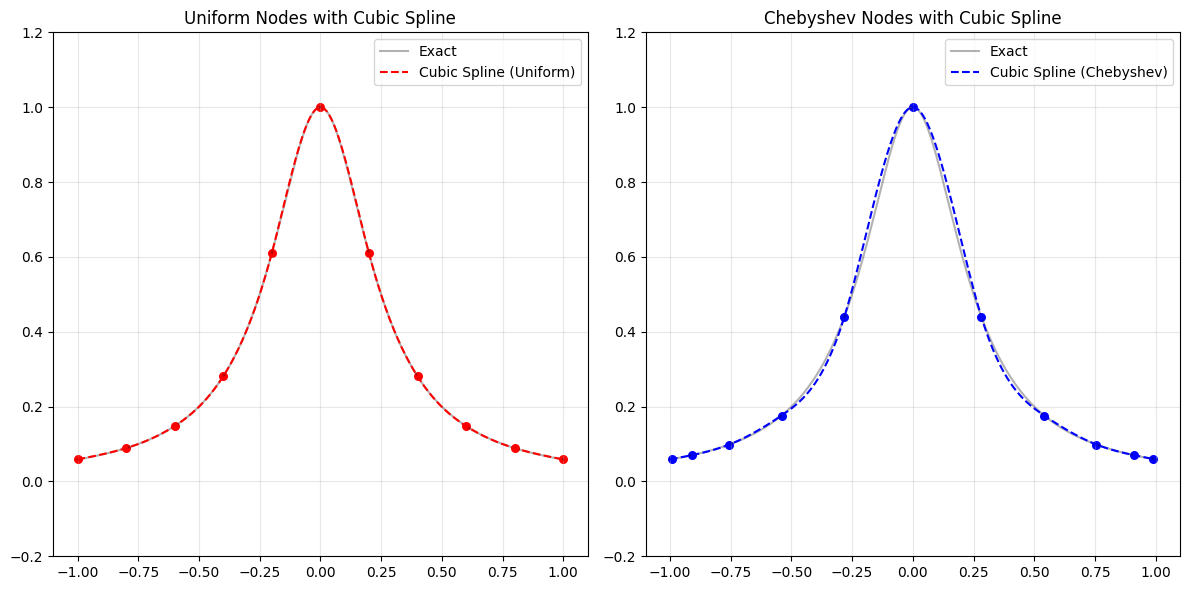

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

def f(x):
    return 1 / (1 + 16 * x**2)

# [1] 균등 노드 (Uniform Nodes) 설정
n = 10
x_uni = np.linspace(-1, 1, n + 1)
y_uni = f(x_uni)

# [2] 체비쇼프 노드 (Chebyshev Nodes) 설정
i = np.arange(n + 1)
x_cheb = np.cos((2 * i + 1) * np.pi / (2 * n + 2))
y_cheb = f(x_cheb)
idx = np.argsort(x_cheb)
x_cheb, y_cheb = x_cheb[idx], y_cheb[idx]

# [3] Cubic Spline 보간 실행 (bc_type='natural' 추가)
cs_uni = CubicSpline(x_uni, y_uni, bc_type='natural')
cs_cheb = CubicSpline(x_cheb, y_cheb, bc_type='natural')

# [4] 시각화
x_plot = np.linspace(-1, 1, 1000)

plt.figure(figsize=(12, 6))

# 첫 번째 그래프: 균등 노드 결과
plt.subplot(1, 2, 1)
plt.plot(x_plot, f(x_plot), 'k', alpha=0.3, label='Exact')
plt.plot(x_plot, cs_uni(x_plot), 'r--', label='Cubic Spline (Uniform)')
plt.scatter(x_uni, y_uni, color='red', s=30)
plt.title('Uniform Nodes with Cubic Spline')
plt.ylim(-0.2, 1.2)
plt.legend()
plt.grid(True, alpha=0.3)

# 두 번째 그래프: 체비쇼프 노드 결과
plt.subplot(1, 2, 2)
plt.plot(x_plot, f(x_plot), 'k', alpha=0.3, label='Exact')
plt.plot(x_plot, cs_cheb(x_plot), 'b--', label='Cubic Spline (Chebyshev)')
plt.scatter(x_cheb, y_cheb, color='blue', s=30)
plt.title('Chebyshev Nodes with Cubic Spline')
plt.ylim(-0.2, 1.2)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

HW_3_1_5

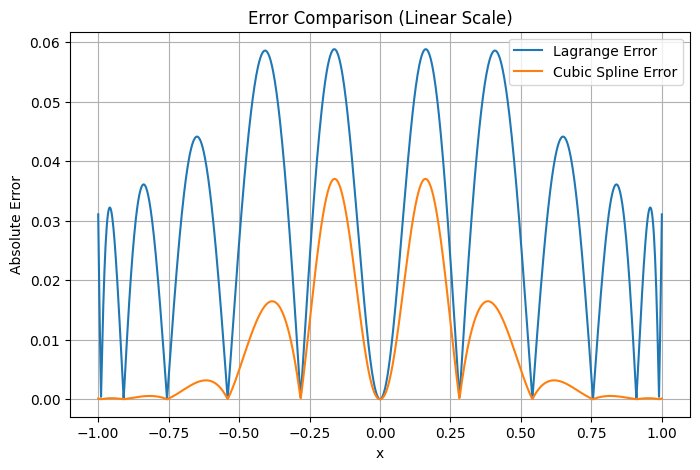

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import BarycentricInterpolator, CubicSpline

def f(x):
    return 1/(1+16*x**2)

n = 10
i = np.arange(0, n+1)
x_c = np.cos((2*i+1)*np.pi/(2*n+2))
y_c = f(x_c)

idx = np.argsort(x_c)
x_c = x_c[idx]
y_c = y_c[idx]

p_lag = BarycentricInterpolator(x_c,y_c)
spline = CubicSpline(x_c, y_c, bc_type='natural')

x_plot = np.linspace(-1,1,1000)
error_lag = np.abs(f(x_plot)-p_lag(x_plot))
error_spline = np.abs(f(x_plot)-spline(x_plot))

plt.figure(figsize=(8,5))
plt.plot(x_plot, error_lag, label='Lagrange Error')
plt.plot(x_plot, error_spline, label='Cubic Spline Error')
plt.xlabel('x')
plt.ylabel('Absolute Error')
plt.title('Error Comparison (Linear Scale)')
plt.legend()
plt.grid(True)
plt.show()

위 그래프를 통해 Cubic Spline interpolation이 Lagrange interpolation 에 비해 훨씬 적은 오차를 보이는 것을 알 수 있고, 더 높은 정확도를 띄는 것을 비교를 통해 알 수 있다.